# HOLa-style predicate description low-rank decomposition

This notebook encodes one text description per scene-graph predicate with the repository-local CLIP text encoder, then follows the HOLa paper's learnable feature decomposition objective:

$$F \approx W B^\top$$

- `F`: CLIP text features, shape `[num_predicates, clip_dim]`
- `W`: learnable predicate-specific weights, shape `[num_predicates, rank]`
- `B`: learnable shared basis features, shape `[clip_dim, rank]`
- `rank`: low-rank dimension `m`

The optimization uses reconstruction loss, L1 sparsity on `W`, and an orthogonality constraint on `B`. If a predicate has no LLM description yet, it falls back to `a photo of {predicate}` and records that in metadata.


## 1. Configuration

Edit this cell before running. For a quick smoke test without the VG dict, set `PREDICATE_JSON = None` and use `PREDICATE_LIST`.

In [9]:
import os

REPO_ROOT = "/Users/shangfei/Developer/SDSGG"

# Use either PREDICATE_JSON or PREDICATE_LIST.
PREDICATE_JSON = "/workspace/ccloud/sf/SDSGG/datasets/vg/VG-SGG-dicts-with-attri.json"
PREDICATE_LIST = None  # Example: ["on", "under", "riding", "holding"]

# Optional LLM descriptions. Supported formats:
# JSON: {"on": "Objects are in contact...", "riding": "..."}
# CSV: columns must be predicate,description
DESCRIPTIONS = "/workspace/ccloud/sf/SDSGG/datasets/vg/descriptions.json"

CLIP_MODEL = "ViT-B/32"  # Or a local checkpoint path, e.g. "/path/to/ViT-B-32.pt"
DEVICE = "cuda"  # Change to "cpu" if needed.
RANK = 16
BATCH_SIZE = 64
NORMALIZE_FEATURES = True
KEEP_BACKGROUND = False
PROMPT_TEMPLATE = "a photo of {predicate}"

# HOLa-style learnable factorization settings.
FACTORIZATION_STEPS = 3000
FACTORIZATION_LR = 1e-2
LAMBDA_SPARSE = 1e-3
LAMBDA_ORTHO = 1e-2
PRINT_EVERY = 250
SEED = 42

OUTPUT = os.path.join(REPO_ROOT, "outputs/hola_predicate_factors.pt")

# Optional VG triplet-statistics inputs for train/test analysis.

# If your environment is missing CLIP tokenizer dependencies, run this once:
# %pip install ftfy regex tqdm


## 2. Imports and helper functions

In [10]:
import csv
import json
import sys
from typing import Dict, List, Optional, Sequence, Tuple

import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

LOCAL_CLIP_PARENT = os.path.join(
    REPO_ROOT, "maskrcnn_benchmark", "modeling", "roi_heads", "relation_head"
)
if LOCAL_CLIP_PARENT not in sys.path:
    sys.path.insert(0, LOCAL_CLIP_PARENT)

print("Repo root:", REPO_ROOT)
print("Local CLIP parent:", LOCAL_CLIP_PARENT)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Repo root: /Users/shangfei/Developer/SDSGG
Local CLIP parent: /Users/shangfei/Developer/SDSGG/maskrcnn_benchmark/modeling/roi_heads/relation_head
Torch: 1.10.1+cu113
CUDA available: True


In [11]:
def normalize_key(text: str) -> str:
    return " ".join(str(text).strip().lower().split())


def load_predicates_from_json(path: str) -> List[Tuple[int, str]]:
    with open(path, "r", encoding="utf-8") as handle:
        payload = json.load(handle)

    if "idx_to_predicate" in payload:
        idx_to_predicate = payload["idx_to_predicate"]
        if isinstance(idx_to_predicate, dict):
            return sorted(
                ((int(index), name) for index, name in idx_to_predicate.items()),
                key=lambda item: item[0],
            )
        return [(index, name) for index, name in enumerate(idx_to_predicate)]

    if "predicate_to_idx" in payload:
        predicate_to_idx = payload["predicate_to_idx"]
        return sorted(
            ((int(index), name) for name, index in predicate_to_idx.items()),
            key=lambda item: item[0],
        )

    raise ValueError(
        f"No predicate mapping found in {path}. Expected idx_to_predicate or predicate_to_idx."
    )


def load_predicates_from_list(predicate_list: Sequence[str]) -> List[Tuple[int, str]]:
    predicates = [item.strip() for item in predicate_list if item and item.strip()]
    if not predicates:
        raise ValueError("PREDICATE_LIST is empty after parsing.")
    return list(enumerate(predicates))


def filter_background(predicates: Sequence[Tuple[int, str]], keep_background: bool) -> List[Tuple[int, str]]:
    if keep_background:
        return list(predicates)
    return [
        (index, name)
        for index, name in predicates
        if normalize_key(name) != "__background__"
    ]

In [12]:
def load_description_map(path: str) -> Dict[str, str]:
    ext = os.path.splitext(path)[1].lower()

    if ext == ".json":
        with open(path, "r", encoding="utf-8") as handle:
            payload = json.load(handle)
        if not isinstance(payload, dict):
            raise ValueError("Description JSON must map predicate -> description.")
        return {normalize_key(key): str(value).strip() for key, value in payload.items()}

    if ext == ".csv":
        description_map = {}
        with open(path, "r", encoding="utf-8", newline="") as handle:
            reader = csv.DictReader(handle)
            required_fields = {"predicate", "description"}
            if not reader.fieldnames or not required_fields.issubset(reader.fieldnames):
                raise ValueError("Description CSV must contain predicate and description columns.")
            for row in reader:
                predicate = normalize_key(row["predicate"])
                description = row["description"].strip()
                if predicate:
                    description_map[predicate] = description
        return description_map

    raise ValueError(f"Unsupported description format: {path}. Use JSON or CSV.")


def resolve_descriptions(
    predicates: Sequence[Tuple[int, str]],
    description_map: Optional[Dict[str, str]],
    prompt_template: str,
) -> Tuple[List[str], List[bool]]:
    descriptions = []
    fallback_mask = []

    for _, predicate_name in predicates:
        description = ""
        if description_map is not None:
            description = description_map.get(normalize_key(predicate_name), "").strip()

        used_fallback = not description
        if used_fallback:
            description = prompt_template.format(predicate=predicate_name)

        descriptions.append(description)
        fallback_mask.append(used_fallback)

    return descriptions, fallback_mask

In [13]:
def encode_text_features(
    texts: Sequence[str],
    clip_model_name: str,
    device: str,
    batch_size: int,
) -> torch.Tensor:
    try:
        from CLIP import clip
    except ModuleNotFoundError as error:
        raise ModuleNotFoundError(
            "Failed to import local CLIP dependencies. "
            "Install the missing package in this notebook kernel, e.g. `%pip install ftfy regex tqdm`. "
            f"Missing package: {error.name}"
        ) from error

    try:
        model, _ = clip.load(clip_model_name, device=device)
    except RuntimeError as error:
        raise RuntimeError(
            "Failed to load CLIP model. If weights are not cached locally, pass a local checkpoint "
            "path in CLIP_MODEL or prepare ~/.cache/clip first. "
            f"Original error: {error}"
        ) from error

    model.eval()
    features = []
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            batch_texts = list(texts[start:start + batch_size])
            tokens = clip.tokenize(batch_texts).to(device)
            batch_features = model.encode_text(tokens).float().cpu()
            features.append(batch_features)

    return torch.cat(features, dim=0)


def effective_rank(requested_rank: int, features: torch.Tensor) -> int:
    if requested_rank < 1:
        raise ValueError("RANK must be positive.")
    return min(requested_rank, features.shape[0], features.shape[1])


def orthogonality_loss(B: torch.Tensor) -> torch.Tensor:
    """Penalize non-orthogonal basis columns, matching HOLa's shared basis constraint."""
    gram = B.t() @ B
    identity = torch.eye(gram.shape[0], device=gram.device, dtype=gram.dtype)
    off_diagonal = gram - identity
    return off_diagonal.pow(2).mean()


def compute_low_rank_factors_learnable(
    features: torch.Tensor,
    requested_rank: int,
    steps: int,
    lr: float,
    lambda_sparse: float,
    lambda_ortho: float,
    seed: int,
    print_every: int,
):
    """Optimize F ~= W @ B.T with HOLa-style sparse W and orthogonal B losses."""
    if steps < 1:
        raise ValueError("FACTORIZATION_STEPS must be positive.")

    target = features.float()
    rank = effective_rank(requested_rank, target)
    num_predicates, feature_dim = target.shape

    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)

    W = torch.randn(num_predicates, rank, generator=generator, dtype=target.dtype) * 0.02
    B = torch.randn(feature_dim, rank, generator=generator, dtype=target.dtype) * 0.02

    # Start B near an orthonormal basis for a stable HOLa-style orthogonal constraint.
    with torch.no_grad():
        q, _ = torch.linalg.qr(torch.randn(feature_dim, rank, generator=generator, dtype=target.dtype), mode="reduced")
        B.copy_(q)

    W = torch.nn.Parameter(W)
    B = torch.nn.Parameter(B)
    optimizer = torch.optim.Adam([W, B], lr=lr)
    history = []

    for step in range(1, steps + 1):
        reconstructed = W @ B.t()
        recon_loss = F.mse_loss(reconstructed, target)
        sparse_loss = W.abs().sum(dim=1).mean()
        ortho_loss = orthogonality_loss(B)
        total_loss = recon_loss + lambda_sparse * sparse_loss + lambda_ortho * ortho_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        if print_every and (step == 1 or step % print_every == 0 or step == steps):
            record = {
                "step": step,
                "total_loss": float(total_loss.detach().cpu()),
                "recon_loss": float(recon_loss.detach().cpu()),
                "sparse_loss": float(sparse_loss.detach().cpu()),
                "ortho_loss": float(ortho_loss.detach().cpu()),
            }
            history.append(record)
            print(record)

    with torch.no_grad():
        final_W = W.detach().cpu()
        final_B = B.detach().cpu()
        reconstructed = final_W @ final_B.t()
        reconstruction_error = torch.norm(target.cpu() - reconstructed, p="fro")
        final_recon_loss = F.mse_loss(reconstructed, target.cpu())
        final_sparse_loss = final_W.abs().sum(dim=1).mean()
        final_ortho_loss = orthogonality_loss(final_B)
        final_total_loss = final_recon_loss + lambda_sparse * final_sparse_loss + lambda_ortho * final_ortho_loss

    return {
        "W": final_W,
        "B": final_B,
        "M": final_B.t(),  # Compatibility alias: F ~= W @ M, while HOLa notation uses B.T.
        "reconstructed": reconstructed,
        "rank": rank,
        "reconstruction_error": reconstruction_error,
        "final_total_loss": final_total_loss,
        "final_recon_loss": final_recon_loss,
        "final_sparse_loss": final_sparse_loss,
        "final_ortho_loss": final_ortho_loss,
        "loss_history": history,
    }


## 3. Load predicates and descriptions

In [14]:
if PREDICATE_JSON and PREDICATE_LIST:
    raise ValueError("Use only one of PREDICATE_JSON or PREDICATE_LIST.")
if not PREDICATE_JSON and not PREDICATE_LIST:
    raise ValueError("Set either PREDICATE_JSON or PREDICATE_LIST.")

if PREDICATE_JSON:
    predicates = load_predicates_from_json(PREDICATE_JSON)
else:
    predicates = load_predicates_from_list(PREDICATE_LIST)

predicates = filter_background(predicates, KEEP_BACKGROUND)
if not predicates:
    raise ValueError("No predicates remain after background filtering.")

description_map = load_description_map(DESCRIPTIONS) if DESCRIPTIONS else None
descriptions, fallback_mask = resolve_descriptions(predicates, description_map, PROMPT_TEMPLATE)

predicate_indices = [index for index, _ in predicates]
predicate_names = [name for _, name in predicates]

print(f"Loaded predicates: {len(predicate_names)}")
print(f"Fallback descriptions: {sum(fallback_mask)}")
print("First predicates:", predicate_names[:10])
print("First descriptions:", descriptions[:3])

Loaded predicates: 50
Fallback descriptions: 0
First predicates: ['above', 'across', 'against', 'along', 'and', 'at', 'attached to', 'behind', 'belonging to', 'between']
First descriptions: ['An object is positioned vertically higher than another object, typically without direct contact and with clear spatial separation.', 'An object extends horizontally or diagonally from one side to another side of a reference object, often spanning its width or length.', 'An object is in physical contact with and leaning on or pressing upon the surface of another object for support or positioning.']


## 4. Encode text with CLIP

In [15]:
print("Step 4: Encode predicate descriptions with CLIP.")
print("- Input text count:", len(descriptions))
print("- CLIP model:", CLIP_MODEL)
print("- Device:", DEVICE)
print("- Normalize features:", NORMALIZE_FEATURES)

features = encode_text_features(
    texts=descriptions,
    clip_model_name=CLIP_MODEL,
    device=DEVICE,
    batch_size=BATCH_SIZE,
)

if NORMALIZE_FEATURES:
    features = F.normalize(features, dim=-1)

print("Done encoding text features.")
print("features shape:", tuple(features.shape), "dtype:", features.dtype)
print("feature norm range:", float(features.norm(dim=-1).min()), float(features.norm(dim=-1).max()))
print("Interpretation: each row is one predicate description embedding; rows are later approximated by W @ B.T.")


Step 4: Encode predicate descriptions with CLIP.
- Input text count: 50
- CLIP model: ViT-B/32
- Device: cuda
- Normalize features: True
Done encoding text features.
features shape: (50, 512) dtype: torch.float32
feature norm range: 0.9999994039535522 1.0000005960464478
Interpretation: each row is one predicate description embedding; rows are later approximated by W @ B.T.


## 5. Compute HOLa-style learnable low-rank factors


In [16]:
print("Step 5: Optimize learnable HOLa-style factors W and B.")
print("Objective: minimize recon_loss + lambda_sparse * ||W||_1 + lambda_ortho * orthogonality(B)")
print("Target matrix F shape:", tuple(features.shape))
print("Requested rank m:", RANK)
print("Optimization steps:", FACTORIZATION_STEPS)
print("Learning rate:", FACTORIZATION_LR)
print("lambda_sparse:", LAMBDA_SPARSE)
print("lambda_ortho:", LAMBDA_ORTHO)

factor_payload = compute_low_rank_factors_learnable(
    features=features,
    requested_rank=RANK,
    steps=FACTORIZATION_STEPS,
    lr=FACTORIZATION_LR,
    lambda_sparse=LAMBDA_SPARSE,
    lambda_ortho=LAMBDA_ORTHO,
    seed=SEED,
    print_every=PRINT_EVERY,
)

W = factor_payload["W"]
B = factor_payload["B"]
M = factor_payload["M"]
reconstructed = factor_payload["reconstructed"]
rank = factor_payload["rank"]

print("\nOptimization finished.")
print("Requested rank:", RANK)
print("Effective rank:", rank)
print("W shape [num_predicates, rank]:", tuple(W.shape))
print("B shape [clip_dim, rank]:", tuple(B.shape))
print("M = B.T shape [rank, clip_dim]:", tuple(M.shape))
print("reconstructed shape:", tuple(reconstructed.shape))
print("reconstruction_error Frobenius:", float(factor_payload["reconstruction_error"]))
print("final_total_loss:", float(factor_payload["final_total_loss"]))
print("final_recon_loss:", float(factor_payload["final_recon_loss"]))
print("final_sparse_loss:", float(factor_payload["final_sparse_loss"]))
print("final_ortho_loss:", float(factor_payload["final_ortho_loss"]))
print("Interpretation: W is predicate-specific; B is the shared semantic basis across predicates.")


Step 5: Optimize learnable HOLa-style factors W and B.
Objective: minimize recon_loss + lambda_sparse * ||W||_1 + lambda_ortho * orthogonality(B)
Target matrix F shape: (50, 512)
Requested rank m: 16
Optimization steps: 3000
Learning rate: 0.01
lambda_sparse: 0.001
lambda_ortho: 0.01
{'step': 1, 'total_loss': 0.002221758710220456, 'recon_loss': 0.0019665523432195187, 'sparse_loss': 0.2552064061164856, 'ortho_loss': 5.5953332075877726e-15}
{'step': 250, 'total_loss': 0.0008409639704041183, 'recon_loss': 0.0002276985178468749, 'sparse_loss': 0.5393227934837341, 'ortho_loss': 0.007394267246127129}
{'step': 500, 'total_loss': 0.0008375905454158783, 'recon_loss': 0.00021541798196267337, 'sparse_loss': 0.5484600067138672, 'ortho_loss': 0.007371252402663231}
{'step': 750, 'total_loss': 0.0008367353002540767, 'recon_loss': 0.00021170977561268955, 'sparse_loss': 0.5512714982032776, 'ortho_loss': 0.007375400513410568}
{'step': 1000, 'total_loss': 0.0008369580027647316, 'recon_loss': 0.0002111987

## 6. Diagnostics A: does the low-rank factorization itself look reasonable?

This section validates the decomposition before using it for any downstream SGG model.

We check four things:

1. **Reconstruction quality**: whether `W @ B.T` preserves CLIP text features.
2. **Loss curve**: whether optimization converged instead of still drifting.
3. **Orthogonality of `B`**: whether basis columns are disentangled rather than duplicated.
4. **Sparsity of `W`**: whether each predicate uses only a small subset of basis features.


Diagnostic A1: Reconstruction quality
What this means:
- Low relative error means W @ B.T keeps most of the original CLIP description feature.
- High cosine means the reconstructed feature points in a similar semantic direction.

Global reconstruction stats:
Frobenius error: 2.29213285446167
Mean per-predicate L2 error: 0.3233003616333008
Median per-predicate L2 error: 0.3212027847766876
Mean relative error: 0.32330045104026794
Median relative error: 0.3212027847766876
Mean cosine(F, reconstructed): 0.9621798992156982
Min cosine(F, reconstructed): 0.9433311820030212

Worst 10 reconstructed predicates by relative error:
{'predicate_index': 4, 'predicate': 'along', 'relative_error': 0.3711, 'cosine': 0.9433, 'used_fallback': False}
{'predicate_index': 34, 'predicate': 'painted on', 'relative_error': 0.3707, 'cosine': 0.9437, 'used_fallback': False}
{'predicate_index': 32, 'predicate': 'on back of', 'relative_error': 0.361, 'cosine': 0.9474, 'used_fallback': False}
{'predicate_index': 3, 

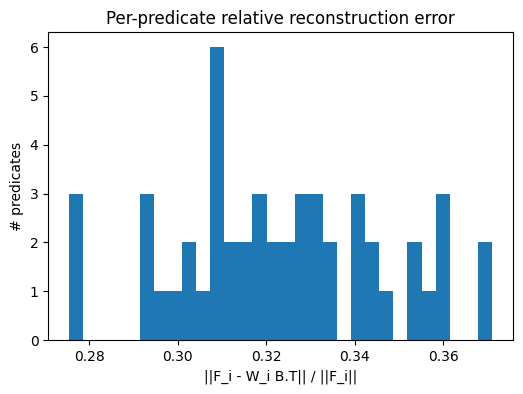

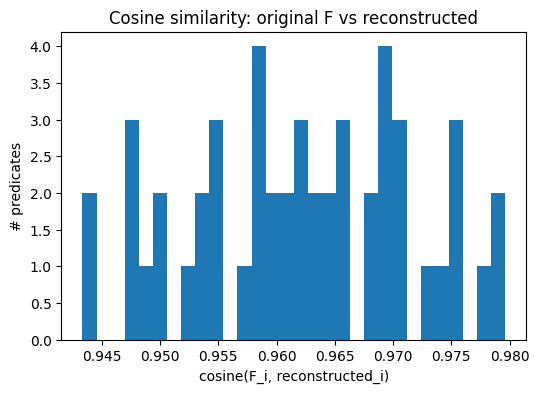

In [17]:
print("Diagnostic A1: Reconstruction quality")

residual = features.cpu() - reconstructed
per_predicate_error = residual.norm(dim=1)
feature_norm = features.cpu().norm(dim=1).clamp_min(1e-12)
relative_error = per_predicate_error / feature_norm
cosine_to_reconstruction = F.cosine_similarity(features.cpu(), reconstructed, dim=1)

print("What this means:")
print("- Low relative error means W @ B.T keeps most of the original CLIP description feature.")
print("- High cosine means the reconstructed feature points in a similar semantic direction.")
print("\nGlobal reconstruction stats:")
print("Frobenius error:", float(factor_payload["reconstruction_error"]))
print("Mean per-predicate L2 error:", float(per_predicate_error.mean()))
print("Median per-predicate L2 error:", float(per_predicate_error.median()))
print("Mean relative error:", float(relative_error.mean()))
print("Median relative error:", float(relative_error.median()))
print("Mean cosine(F, reconstructed):", float(cosine_to_reconstruction.mean()))
print("Min cosine(F, reconstructed):", float(cosine_to_reconstruction.min()))

worst_k = min(10, len(predicate_names))
worst_indices = torch.argsort(relative_error, descending=True)[:worst_k].tolist()
print(f"\nWorst {worst_k} reconstructed predicates by relative error:")
for row_id in worst_indices:
    print({
        "predicate_index": predicate_indices[row_id],
        "predicate": predicate_names[row_id],
        "relative_error": round(float(relative_error[row_id]), 4),
        "cosine": round(float(cosine_to_reconstruction[row_id]), 4),
        "used_fallback": bool(fallback_mask[row_id]),
    })

plt.figure(figsize=(6, 4))
plt.hist(relative_error.numpy(), bins=30)
plt.title("Per-predicate relative reconstruction error")
plt.xlabel("||F_i - W_i B.T|| / ||F_i||")
plt.ylabel("# predicates")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(cosine_to_reconstruction.numpy(), bins=30)
plt.title("Cosine similarity: original F vs reconstructed")
plt.xlabel("cosine(F_i, reconstructed_i)")
plt.ylabel("# predicates")
plt.show()


Diagnostic A2: Optimization loss curve
First record: {'step': 1, 'total_loss': 0.002221758710220456, 'recon_loss': 0.0019665523432195187, 'sparse_loss': 0.2552064061164856, 'ortho_loss': 5.5953332075877726e-15}
Last record: {'step': 3000, 'total_loss': 0.0008354638703167439, 'recon_loss': 0.00020589519408531487, 'sparse_loss': 0.556000292301178, 'ortho_loss': 0.007356834597885609}
What to look for: total_loss and recon_loss should decrease and then stabilize.


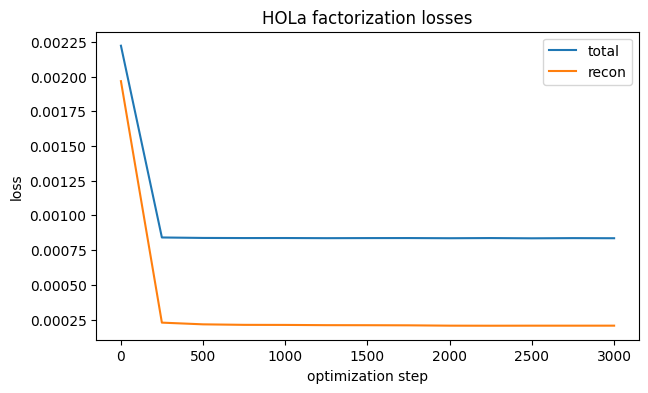

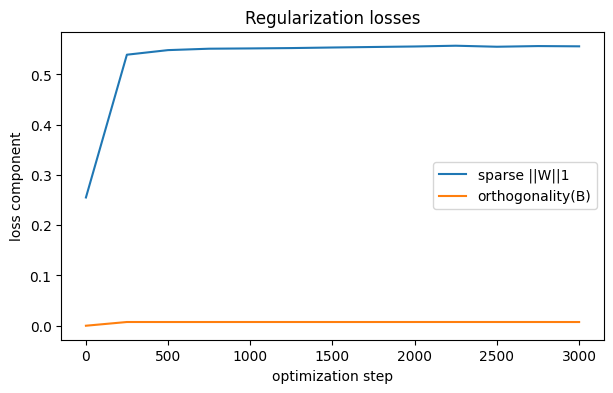

In [18]:
print("Diagnostic A2: Optimization loss curve")

history = factor_payload["loss_history"]
if not history:
    print("No loss history was recorded. Set PRINT_EVERY to a positive value.")
else:
    steps = [item["step"] for item in history]
    total_losses = [item["total_loss"] for item in history]
    recon_losses = [item["recon_loss"] for item in history]
    sparse_losses = [item["sparse_loss"] for item in history]
    ortho_losses = [item["ortho_loss"] for item in history]

    print("First record:", history[0])
    print("Last record:", history[-1])
    print("What to look for: total_loss and recon_loss should decrease and then stabilize.")

    plt.figure(figsize=(7, 4))
    plt.plot(steps, total_losses, label="total")
    plt.plot(steps, recon_losses, label="recon")
    plt.xlabel("optimization step")
    plt.ylabel("loss")
    plt.title("HOLa factorization losses")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(steps, sparse_losses, label="sparse ||W||1")
    plt.plot(steps, ortho_losses, label="orthogonality(B)")
    plt.xlabel("optimization step")
    plt.ylabel("loss component")
    plt.title("Regularization losses")
    plt.legend()
    plt.show()


Diagnostic A3: Basis orthogonality
What this means:
- B.T @ B should be close to identity if basis features are non-redundant.
- Off-diagonal values near 0 mean different basis vectors are less correlated.

Basis norm stats:
min norm: 0.9989052414894104
mean norm: 1.039388656616211
max norm: 1.5406935214996338

Orthogonality stats:
mean abs off-diagonal: 0.002125015016645193
max abs off-diagonal: 0.014952929690480232
mean squared B.TB-I: 0.007395140361040831


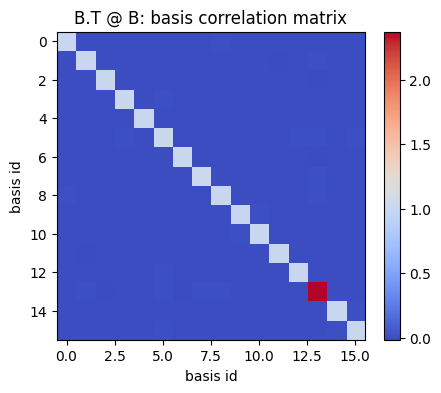

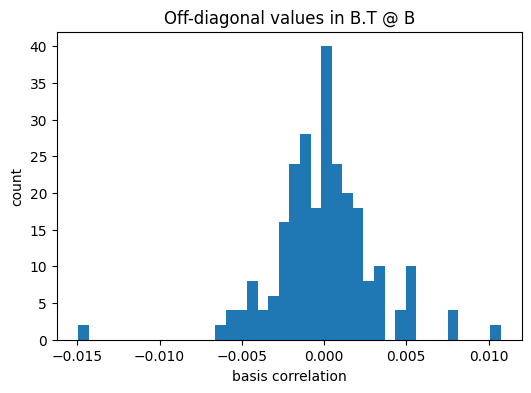

In [19]:
print("Diagnostic A3: Basis orthogonality")

B_gram = B.t() @ B
identity = torch.eye(B_gram.shape[0])
off_diag = B_gram - torch.diag(torch.diag(B_gram))
basis_norms = B.norm(dim=0)

print("What this means:")
print("- B.T @ B should be close to identity if basis features are non-redundant.")
print("- Off-diagonal values near 0 mean different basis vectors are less correlated.")
print("\nBasis norm stats:")
print("min norm:", float(basis_norms.min()))
print("mean norm:", float(basis_norms.mean()))
print("max norm:", float(basis_norms.max()))
print("\nOrthogonality stats:")
print("mean abs off-diagonal:", float(off_diag.abs().mean()))
print("max abs off-diagonal:", float(off_diag.abs().max()))
print("mean squared B.TB-I:", float((B_gram - identity).pow(2).mean()))

plt.figure(figsize=(5, 4))
plt.imshow(B_gram.numpy(), cmap="coolwarm")
plt.colorbar()
plt.title("B.T @ B: basis correlation matrix")
plt.xlabel("basis id")
plt.ylabel("basis id")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(off_diag.flatten().numpy(), bins=40)
plt.title("Off-diagonal values in B.T @ B")
plt.xlabel("basis correlation")
plt.ylabel("count")
plt.show()


Diagnostic A4: Weight sparsity
What this means:
- Fewer active basis dimensions per predicate means W is more sparse/compositional.
- If every predicate activates every basis, increase LAMBDA_SPARSE or reduce RANK.
{'threshold': 0.001, 'mean_active_basis': 8.78, 'median_active_basis': 9.0, 'min_active_basis': 3, 'max_active_basis': 14}
{'threshold': 0.01, 'mean_active_basis': 1.26, 'median_active_basis': 1.0, 'min_active_basis': 1, 'max_active_basis': 2}
{'threshold': 0.05, 'mean_active_basis': 1.2, 'median_active_basis': 1.0, 'min_active_basis': 1, 'max_active_basis': 2}
{'threshold': 0.1, 'mean_active_basis': 1.14, 'median_active_basis': 1.0, 'min_active_basis': 1, 'max_active_basis': 2}

W magnitude stats:
mean L1 per predicate: 0.5557054281234741
median L1 per predicate: 0.5349946618080139
mean max |weight| per predicate: 0.5089508295059204


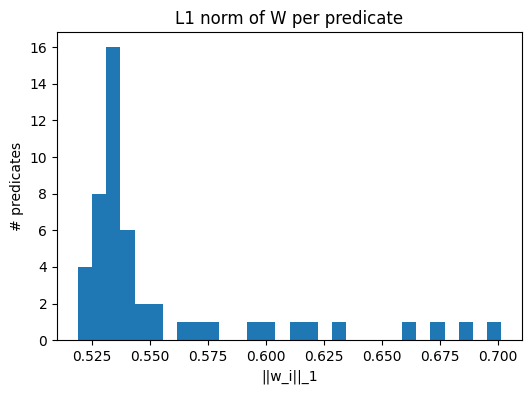

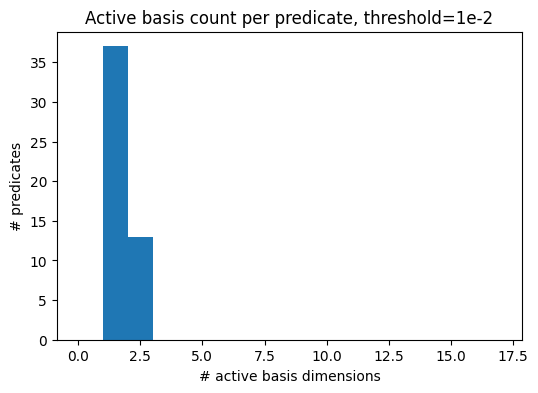

In [20]:
print("Diagnostic A4: Weight sparsity")

abs_W = W.abs()
thresholds = [1e-3, 1e-2, 5e-2, 1e-1]
print("What this means:")
print("- Fewer active basis dimensions per predicate means W is more sparse/compositional.")
print("- If every predicate activates every basis, increase LAMBDA_SPARSE or reduce RANK.")

for threshold in thresholds:
    active_counts = (abs_W > threshold).sum(dim=1)
    print({
        "threshold": threshold,
        "mean_active_basis": round(float(active_counts.float().mean()), 3),
        "median_active_basis": round(float(active_counts.float().median()), 3),
        "min_active_basis": int(active_counts.min()),
        "max_active_basis": int(active_counts.max()),
    })

l1_per_predicate = abs_W.sum(dim=1)
max_weight_per_predicate = abs_W.max(dim=1).values
print("\nW magnitude stats:")
print("mean L1 per predicate:", float(l1_per_predicate.mean()))
print("median L1 per predicate:", float(l1_per_predicate.median()))
print("mean max |weight| per predicate:", float(max_weight_per_predicate.mean()))

plt.figure(figsize=(6, 4))
plt.hist(l1_per_predicate.numpy(), bins=30)
plt.title("L1 norm of W per predicate")
plt.xlabel("||w_i||_1")
plt.ylabel("# predicates")
plt.show()

active_counts = (abs_W > 1e-2).sum(dim=1)
plt.figure(figsize=(6, 4))
plt.hist(active_counts.numpy(), bins=range(0, rank + 2))
plt.title("Active basis count per predicate, threshold=1e-2")
plt.xlabel("# active basis dimensions")
plt.ylabel("# predicates")
plt.show()


## 7. Diagnostics B: does the decomposition reveal useful predicate semantics?

This section checks whether the learned representation is semantically meaningful, not just numerically reconstructive.

We compare three spaces:

- `F`: original CLIP description features.
- `F_hat = W @ B.T`: low-rank reconstructed features.
- `W`: sparse predicate weights over shared basis features.

Useful signs:

- Similar predicates become neighbors in `W` or `F_hat`.
- Each basis dimension has interpretable high-weight predicates.
- Fallback descriptions are easy to identify, because they may be less semantically rich than future LLM descriptions.


In [21]:
def cosine_similarity_matrix(x: torch.Tensor) -> torch.Tensor:
    x = F.normalize(x.float(), dim=-1)
    return x @ x.t()


def topk_neighbors(similarity: torch.Tensor, row_id: int, k: int = 5):
    values, indices = torch.topk(similarity[row_id], k=min(k + 1, similarity.shape[0]))
    neighbors = []
    for value, index in zip(values.tolist(), indices.tolist()):
        if index == row_id:
            continue
        neighbors.append((index, value))
        if len(neighbors) == k:
            break
    return neighbors


sim_F = cosine_similarity_matrix(features.cpu())
sim_reconstructed = cosine_similarity_matrix(reconstructed)
sim_W = cosine_similarity_matrix(W)

print("Diagnostic B1: Nearest-neighbor predicate comparison")
print("What this means:")
print("- F neighbors show CLIP's original predicate-description similarity.")
print("- F_hat neighbors show the denoised low-rank semantic space.")
print("- W neighbors show predicates that use similar shared basis combinations.")
print("- If W/F_hat neighbors are semantically cleaner than F, the decomposition is useful for analysis.")

query_predicates = ["on", "under", "riding", "holding", "wearing", "near", "behind", "in front of"]
available = {normalize_key(name): i for i, name in enumerate(predicate_names)}
query_rows = [available[normalize_key(name)] for name in query_predicates if normalize_key(name) in available]
if not query_rows:
    query_rows = list(range(min(8, len(predicate_names))))

for row_id in query_rows:
    print("\nQuery:", {"predicate_index": predicate_indices[row_id], "predicate": predicate_names[row_id]})
    for label, sim in [("Original F", sim_F), ("Reconstructed F_hat", sim_reconstructed), ("Weight W", sim_W)]:
        neighbors = topk_neighbors(sim, row_id, k=5)
        formatted = [
            {"predicate": predicate_names[idx], "score": round(score, 4)}
            for idx, score in neighbors
        ]
        print(label, formatted)


Diagnostic B1: Nearest-neighbor predicate comparison
What this means:
- F neighbors show CLIP's original predicate-description similarity.
- F_hat neighbors show the denoised low-rank semantic space.
- W neighbors show predicates that use similar shared basis combinations.
- If W/F_hat neighbors are semantically cleaner than F, the decomposition is useful for analysis.

Query: {'predicate_index': 31, 'predicate': 'on'}
Original F [{'predicate': 'standing on', 'score': 0.9512}, {'predicate': 'sitting on', 'score': 0.9484}, {'predicate': 'under', 'score': 0.9435}, {'predicate': 'laying on', 'score': 0.9358}, {'predicate': 'made of', 'score': 0.933}]
Reconstructed F_hat [{'predicate': 'using', 'score': 1.0}, {'predicate': 'in front of', 'score': 1.0}, {'predicate': 'watching', 'score': 1.0}, {'predicate': 'above', 'score': 1.0}, {'predicate': 'to', 'score': 1.0}]
Weight W [{'predicate': 'using', 'score': 1.0}, {'predicate': 'in front of', 'score': 1.0}, {'predicate': 'watching', 'score': 

In [22]:
print("Diagnostic B2: Basis interpretation from W")
print("What this means:")
print("- For each basis dimension k, predicates with the largest positive/negative W[:, k] reveal what that basis may encode.")
print("- If the top predicates share a recognizable relation type, that basis is interpretable.")

TOPK_PER_BASIS = 8
for basis_id in range(rank):
    weights = W[:, basis_id]
    top_pos = torch.topk(weights, k=min(TOPK_PER_BASIS, len(predicate_names))).indices.tolist()
    top_neg = torch.topk(-weights, k=min(TOPK_PER_BASIS, len(predicate_names))).indices.tolist()
    print(f"\nBasis {basis_id}")
    print("  Top positive predicates:")
    for row_id in top_pos:
        print("   ", {"predicate": predicate_names[row_id], "weight": round(float(weights[row_id]), 4)})
    print("  Top negative predicates:")
    for row_id in top_neg:
        print("   ", {"predicate": predicate_names[row_id], "weight": round(float(weights[row_id]), 4)})


Diagnostic B2: Basis interpretation from W
What this means:
- For each basis dimension k, predicates with the largest positive/negative W[:, k] reveal what that basis may encode.
- If the top predicates share a recognizable relation type, that basis is interpretable.

Basis 0
  Top positive predicates:
    {'predicate': 'laying on', 'weight': 0.0034}
    {'predicate': 'under', 'weight': 0.0031}
    {'predicate': 'for', 'weight': 0.0025}
    {'predicate': 'covered in', 'weight': 0.0022}
    {'predicate': 'walking on', 'weight': 0.002}
    {'predicate': 'over', 'weight': 0.0018}
    {'predicate': 'from', 'weight': 0.0016}
    {'predicate': 'made of', 'weight': 0.0015}
  Top negative predicates:
    {'predicate': 'wears', 'weight': -0.0342}
    {'predicate': 'flying in', 'weight': -0.0034}
    {'predicate': 'riding', 'weight': -0.0033}
    {'predicate': 'has', 'weight': -0.0032}
    {'predicate': 'behind', 'weight': -0.0029}
    {'predicate': 'covering', 'weight': -0.0024}
    {'predicate

In [23]:
print("Diagnostic B3: Predicate-basis activation table")
print("What this means:")
print("- This shows which basis dimensions each predicate relies on most.")
print("- Sparse, meaningful top dimensions support the claim that predicates are combinations of shared basis features.")

TOPK_BASIS_PER_PREDICATE = min(5, rank)
rows_to_show = query_rows[:]
if len(rows_to_show) < min(10, len(predicate_names)):
    rows_to_show += [i for i in range(len(predicate_names)) if i not in rows_to_show][: min(10, len(predicate_names)) - len(rows_to_show)]

for row_id in rows_to_show:
    weights = W[row_id]
    top_dims = torch.topk(weights.abs(), k=TOPK_BASIS_PER_PREDICATE).indices.tolist()
    print("\nPredicate:", {"predicate_index": predicate_indices[row_id], "predicate": predicate_names[row_id]})
    print("Description:", descriptions[row_id])
    print("Used fallback:", bool(fallback_mask[row_id]))
    print("Top basis activations:")
    for basis_id in top_dims:
        print(" ", {"basis": basis_id, "weight": round(float(weights[basis_id]), 4)})


Diagnostic B3: Predicate-basis activation table
What this means:
- This shows which basis dimensions each predicate relies on most.
- Sparse, meaningful top dimensions support the claim that predicates are combinations of shared basis features.

Predicate: {'predicate_index': 31, 'predicate': 'on'}
Description: An object is physically supported by and in direct contact with the upper surface of another object.
Used fallback: False
Top basis activations:
  {'basis': 13, 'weight': 0.5148}
  {'basis': 6, 'weight': -0.0035}
  {'basis': 7, 'weight': -0.0026}
  {'basis': 4, 'weight': 0.0021}
  {'basis': 5, 'weight': 0.0016}

Predicate: {'predicate_index': 43, 'predicate': 'under'}
Description: An object is positioned below another object, often with the upper object providing coverage, support, or occlusion.
Used fallback: False
Top basis activations:
  {'basis': 13, 'weight': 0.5167}
  {'basis': 10, 'weight': 0.0036}
  {'basis': 0, 'weight': 0.0031}
  {'basis': 14, 'weight': -0.003}
  {'bas

Diagnostic B4: 2D visualization of predicate spaces
What this means:
- These PCA plots are only exploratory, but clusters can reveal whether low-rank W creates cleaner semantic grouping.
- Labels are omitted by default to keep the plot readable; inspect nearest-neighbor tables for exact semantics.


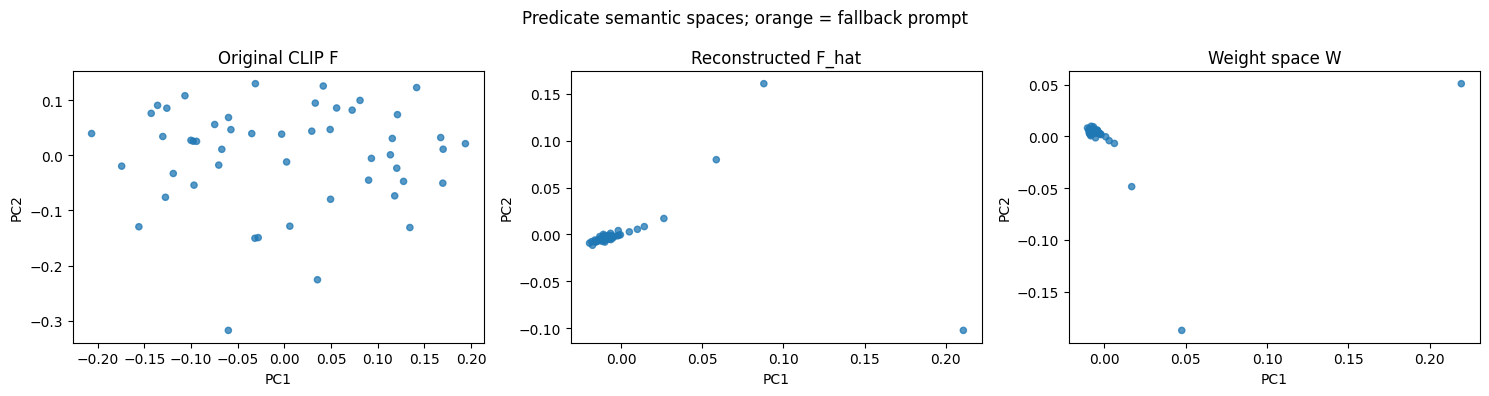

In [24]:
print("Diagnostic B4: 2D visualization of predicate spaces")
print("What this means:")
print("- These PCA plots are only exploratory, but clusters can reveal whether low-rank W creates cleaner semantic grouping.")
print("- Labels are omitted by default to keep the plot readable; inspect nearest-neighbor tables for exact semantics.")


def pca_2d(x: torch.Tensor) -> torch.Tensor:
    x = x.float()
    x = x - x.mean(dim=0, keepdim=True)
    u, s, vh = torch.linalg.svd(x, full_matrices=False)
    return x @ vh[:2].t()

coords_F = pca_2d(features.cpu())
coords_reconstructed = pca_2d(reconstructed)
coords_W = pca_2d(W)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, coords, title in [
    (axes[0], coords_F, "Original CLIP F"),
    (axes[1], coords_reconstructed, "Reconstructed F_hat"),
    (axes[2], coords_W, "Weight space W"),
]:
    colors = ["tab:orange" if used else "tab:blue" for used in fallback_mask]
    ax.scatter(coords[:, 0].numpy(), coords[:, 1].numpy(), s=20, c=colors, alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

fig.suptitle("Predicate semantic spaces; orange = fallback prompt")
plt.tight_layout()
plt.show()


In [25]:
print("Diagnostic B5: Fallback prompt audit")
print("What this means:")
print("- Fallback rows use only predicate-name prompts. Once you add LLM descriptions, these should decrease.")
print("- If fallback rows dominate, semantic analysis mainly reflects predicate names, not rich descriptions.")

fallback_examples = [
    (idx, name, desc)
    for idx, name, desc, used_fallback in zip(predicate_indices, predicate_names, descriptions, fallback_mask)
    if used_fallback
]

print(f"Fallback rows: {len(fallback_examples)} / {len(predicate_names)}")
print("First fallback examples:")
fallback_examples[:20]


Diagnostic B5: Fallback prompt audit
What this means:
- Fallback rows use only predicate-name prompts. Once you add LLM descriptions, these should decrease.
- If fallback rows dominate, semantic analysis mainly reflects predicate names, not rich descriptions.
Fallback rows: 0 / 50
First fallback examples:


[]

## 8. Save `.pt` factors and `.json` metadata


In [26]:
def metadata_path(output_path: str) -> str:
    root, _ = os.path.splitext(output_path)
    return root + ".json"


os.makedirs(os.path.dirname(OUTPUT), exist_ok=True)

output_payload = {
    "features": features,
    "W": W,
    "B": B,
    "M": M,
    "reconstructed": reconstructed,
    "predicate_names": predicate_names,
    "predicate_indices": predicate_indices,
    "descriptions": descriptions,
    "rank": rank,
    "reconstruction_error": float(factor_payload["reconstruction_error"]),
    "final_total_loss": float(factor_payload["final_total_loss"]),
    "final_recon_loss": float(factor_payload["final_recon_loss"]),
    "final_sparse_loss": float(factor_payload["final_sparse_loss"]),
    "final_ortho_loss": float(factor_payload["final_ortho_loss"]),
    "loss_history": factor_payload["loss_history"],
    "factorization_method": "learnable_hola",
}

metadata = {
    "predicate_json": PREDICATE_JSON,
    "descriptions": DESCRIPTIONS,
    "clip_model": CLIP_MODEL,
    "device": DEVICE,
    "normalize": NORMALIZE_FEATURES,
    "requested_rank": RANK,
    "effective_rank": rank,
    "factorization_steps": FACTORIZATION_STEPS,
    "factorization_lr": FACTORIZATION_LR,
    "lambda_sparse": LAMBDA_SPARSE,
    "lambda_ortho": LAMBDA_ORTHO,
    "seed": SEED,
    "num_predicates": len(predicate_names),
    "feature_dim": int(features.shape[1]),
    "fallback_count": int(sum(fallback_mask)),
    "fallback_mask": fallback_mask,
    "predicate_names": predicate_names,
    "predicate_indices": predicate_indices,
    "description_texts": descriptions,
    "reconstruction_error": float(factor_payload["reconstruction_error"]),
    "final_total_loss": float(factor_payload["final_total_loss"]),
    "final_recon_loss": float(factor_payload["final_recon_loss"]),
    "final_sparse_loss": float(factor_payload["final_sparse_loss"]),
    "final_ortho_loss": float(factor_payload["final_ortho_loss"]),
    "loss_history": factor_payload["loss_history"],
    "factorization_method": "learnable_hola",
}

torch.save(output_payload, OUTPUT)
META_OUTPUT = metadata_path(OUTPUT)
with open(META_OUTPUT, "w", encoding="utf-8") as handle:
    json.dump(metadata, handle, ensure_ascii=False, indent=2)

print("Saved factors:", OUTPUT)
print("Saved metadata:", META_OUTPUT)


PermissionError: [Errno 13] Permission denied: '/Users'